# MP2 Part 2: Commit Activity Visualization (lwang111)

Aggregates the Part 1 commits into monthly time series, plots each project, and computes inactivity-gap stats.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

NETID = "lwang111"
MIN_GAP_MONTHS = 3

TIMESERIES_CSV_DIR = Path("timeseries_csv")
TIMESERIES_PLOT_DIR = Path("timeseries_plots")
TIMESERIES_CSV_DIR.mkdir(exist_ok=True)
TIMESERIES_PLOT_DIR.mkdir(exist_ok=True)

## Load commits from Part 1

In [2]:
commits = pd.read_csv(f"{NETID}_project_summary.csv", sep=";")
commits.columns = ["project", "commit", "author", "time", "message"]

commit_datetimes = pd.to_datetime(commits["time"], unit="s")
commits["Month"] = commit_datetimes.dt.to_period("M")

projects = sorted(commits["project"].unique())
commits.groupby("project").size()

project
asgr_profound                              631
homalg-project_toricvarieties_project     2445
lanl_elements                              638
ldbc_sigmod2014-pc                         536
libatoms_quip                            11907
nanocomp_meep                             9022
opticspy_lightpipes                        341
ph-rast_bmgarch                            504
wiris_moodle-filter_wiris                 1476
wurmlab_sequenceserver                    3683
dtype: int64

## Build monthly time series

One row per month from the first to the last commit month, with zero-commit months filled in as 0.

In [3]:
# Count commits per month for one project, including months with zero commits.
def build_monthly_commit_counts(project_commits):
    counts_by_month = project_commits.groupby("Month").size()

    first_month = counts_by_month.index.min()
    last_month = counts_by_month.index.max()
    all_months = pd.period_range(first_month, last_month, freq="M")
    filled_counts = counts_by_month.reindex(all_months, fill_value=0)

    timeseries = pd.DataFrame({
        "Month": filled_counts.index.strftime("%Y-%m"),
        "#Commits": filled_counts.values,
    })
    return timeseries


timeseries_by_project = {}
for project in projects:
    project_commits = commits[commits["project"] == project]
    timeseries = build_monthly_commit_counts(project_commits)
    csv_path = TIMESERIES_CSV_DIR / f"{NETID}_commits_timeseries_{project}.csv"
    timeseries.to_csv(csv_path, sep=";", index=False)
    timeseries_by_project[project] = timeseries

timeseries_by_project[projects[0]].head()

,Month,#Commits
0,2017-08,30
1,2017-09,18
2,2017-10,1
3,2017-11,4
4,2017-12,12


## Plot each time series

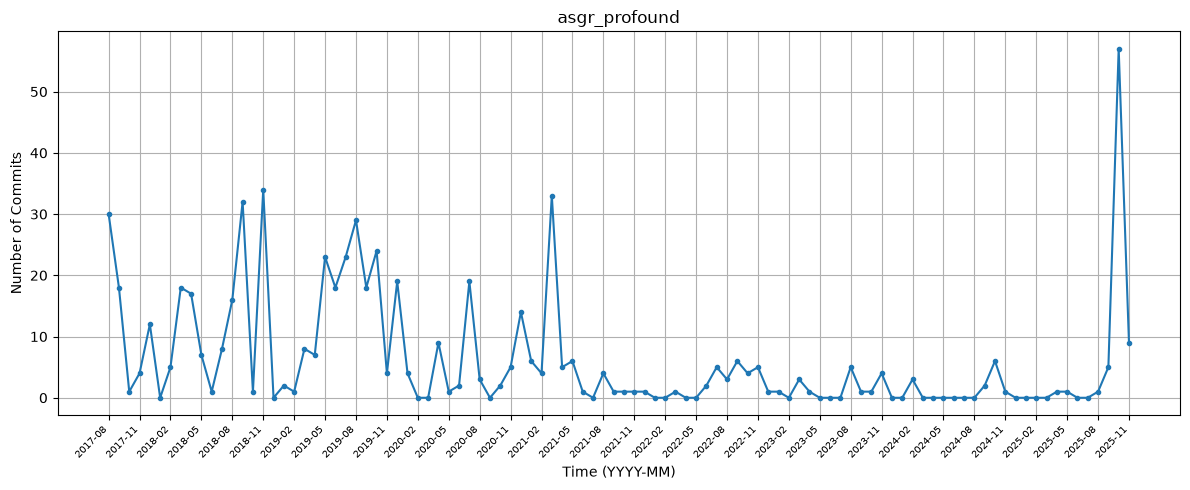

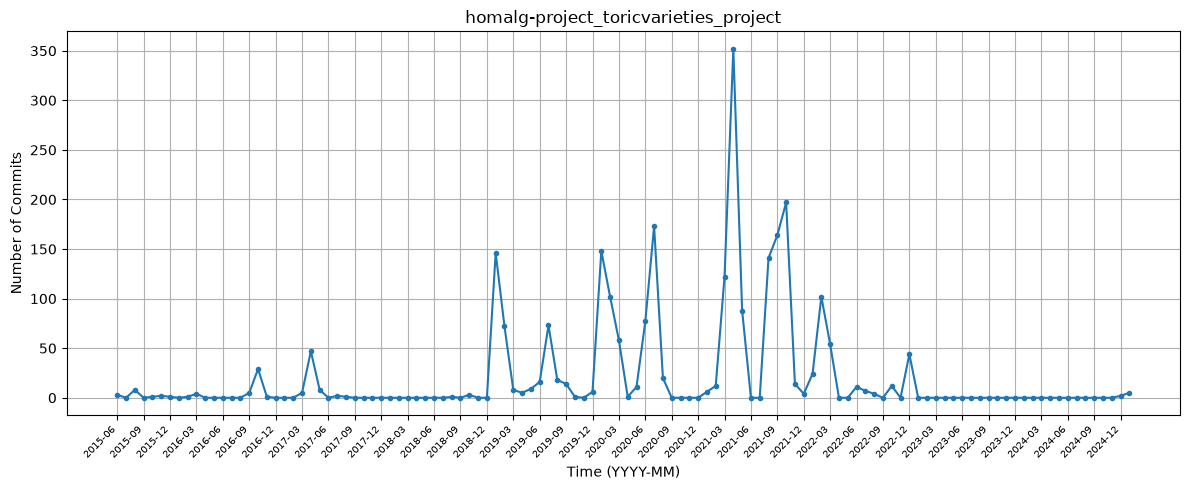

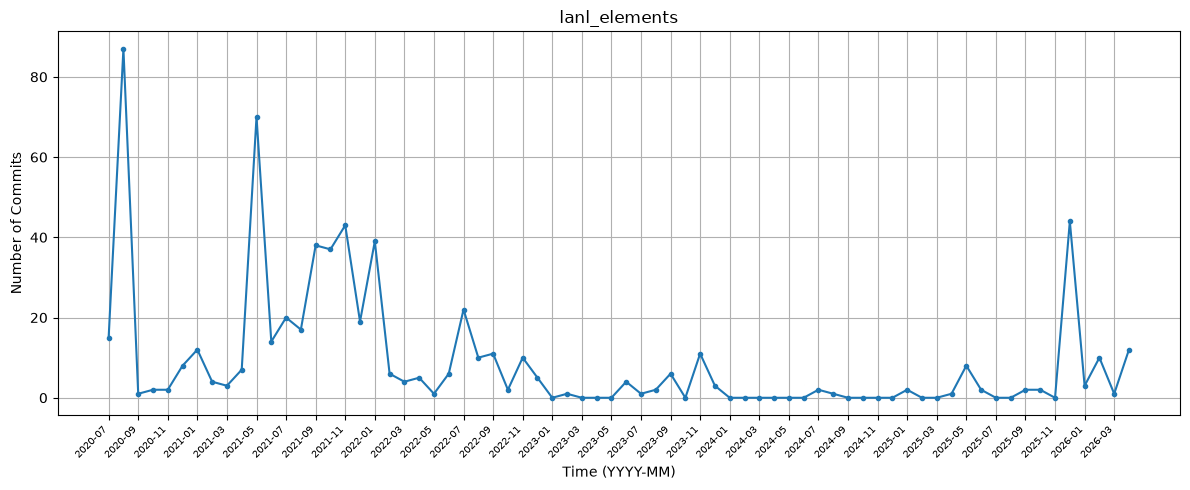

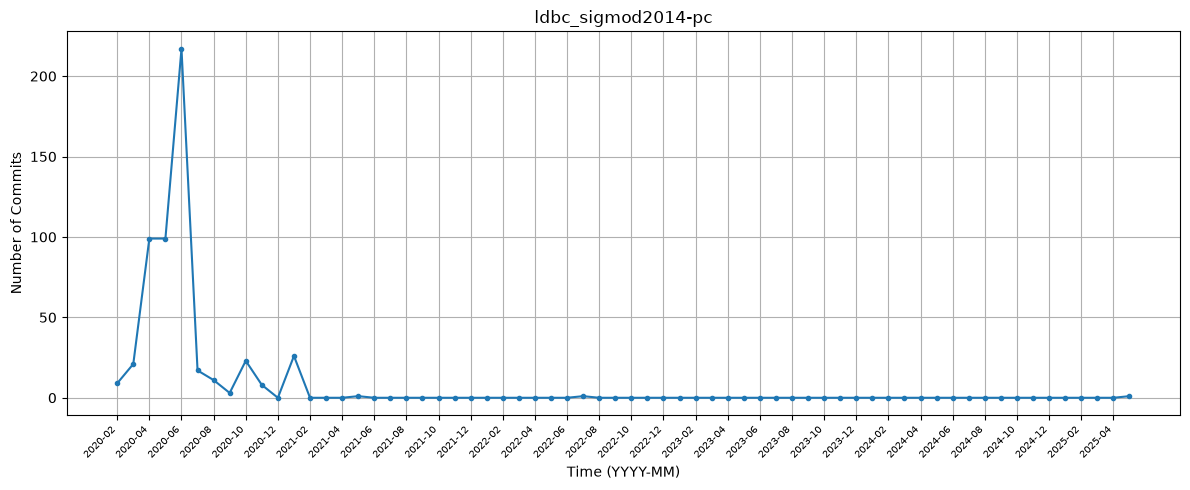

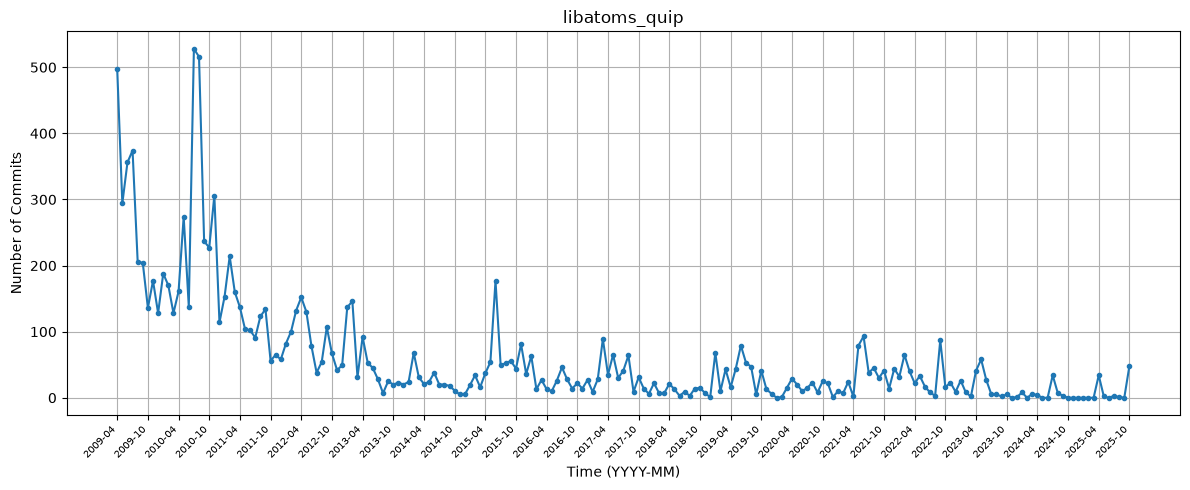

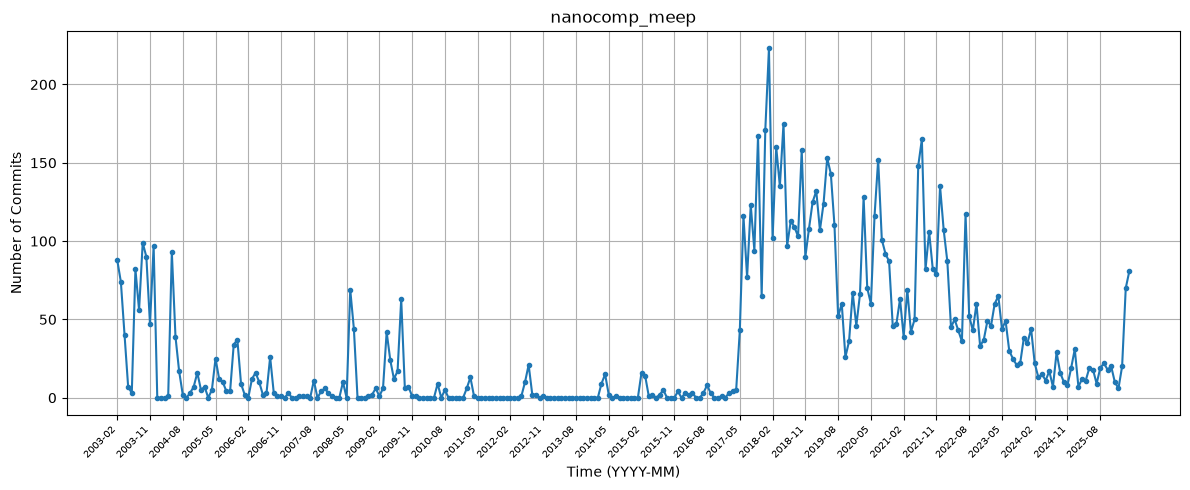

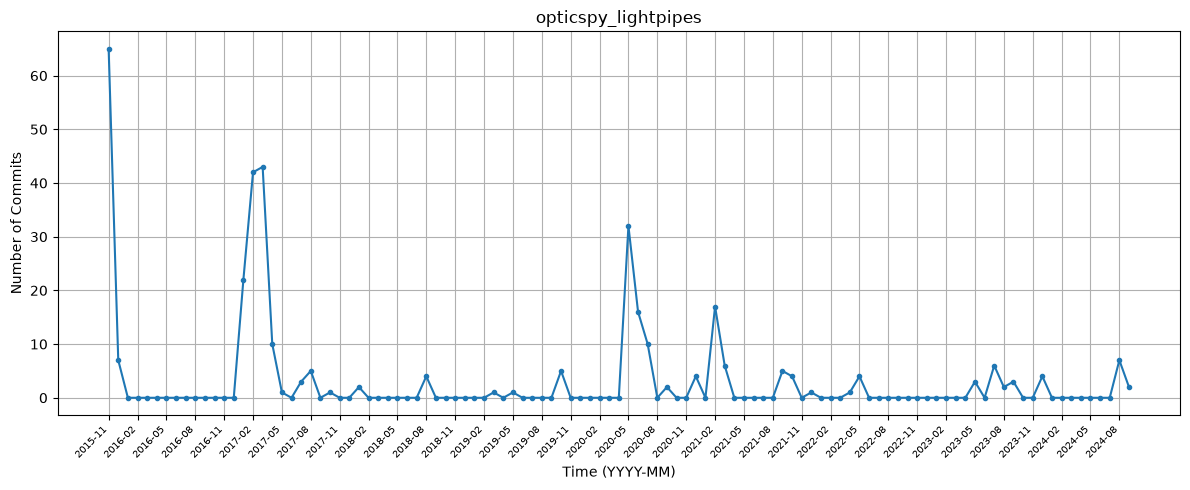

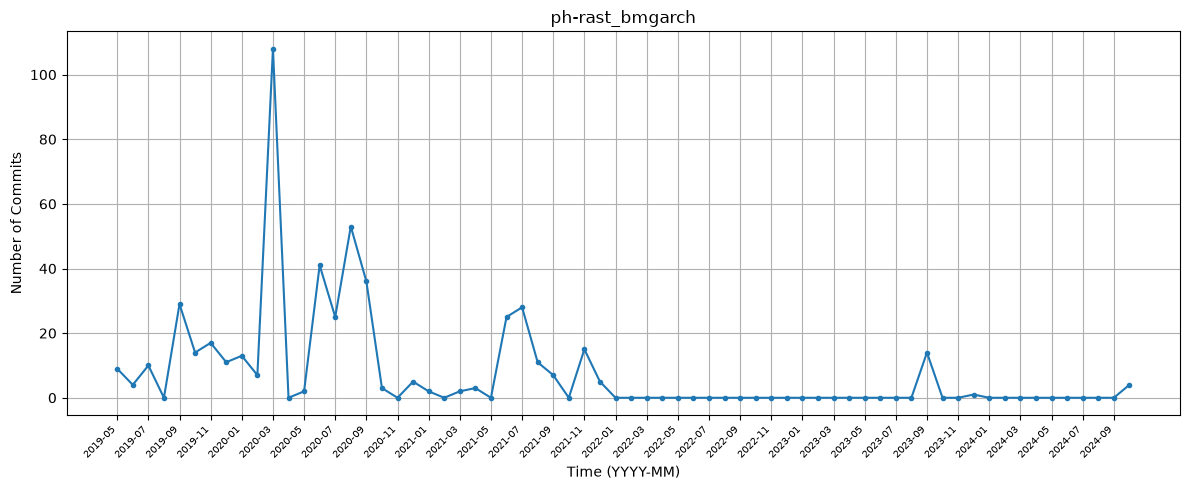

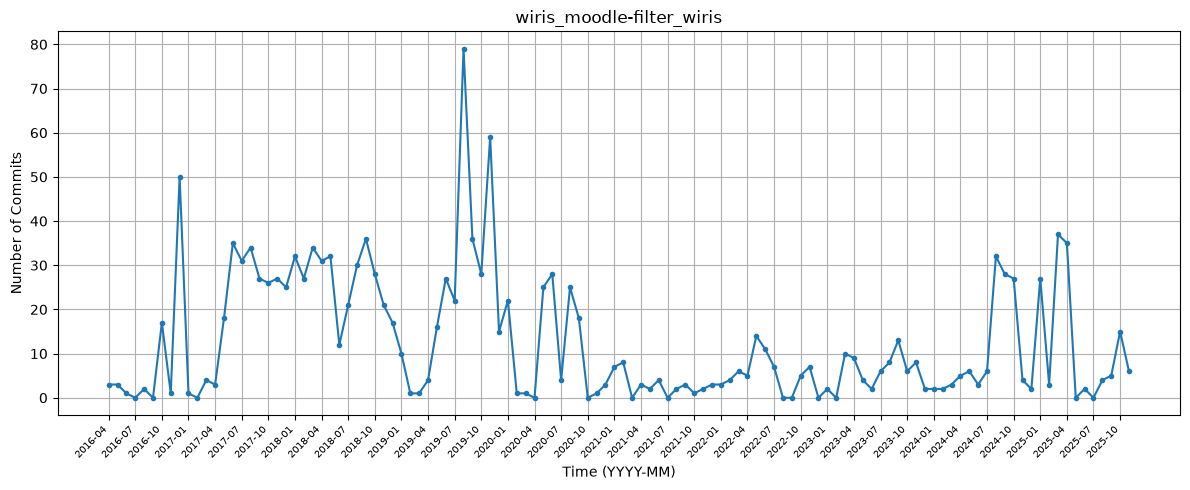

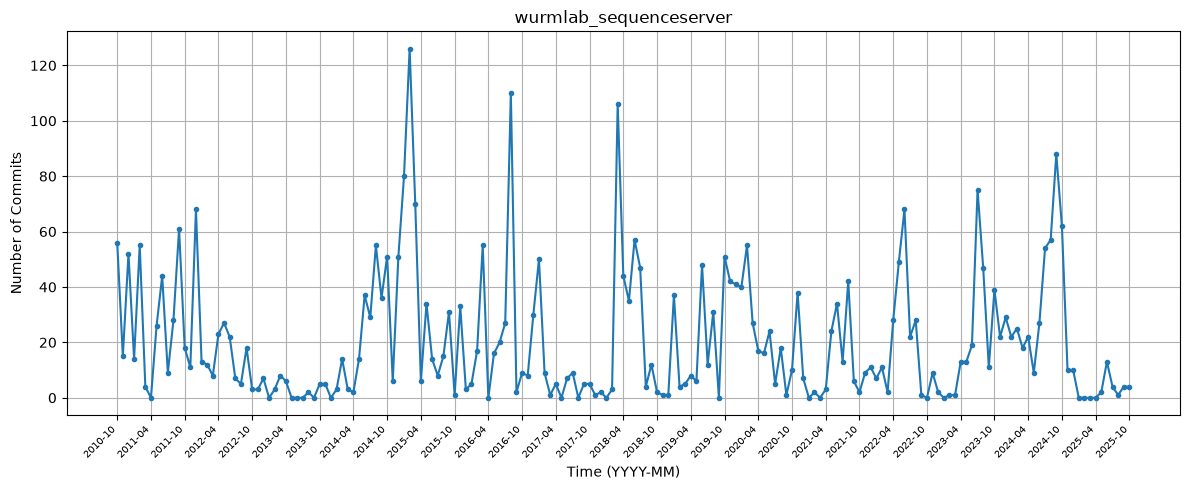

In [4]:
# Save a 300 DPI line plot of one project's monthly commit counts.
def plot_monthly_commits(project, timeseries):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(timeseries["Month"], timeseries["#Commits"], marker="o", markersize=3, linestyle="-")

    ax.set_xlabel("Time (YYYY-MM)")
    ax.set_ylabel("Number of Commits")
    ax.set_title(project)
    ax.grid(True)

    # Long histories have hundreds of months, so only label about 30 ticks to keep them legible.
    tick_step = max(1, len(timeseries) // 30)
    tick_positions = range(0, len(timeseries), tick_step)
    tick_labels = timeseries["Month"].iloc[::tick_step]
    ax.set_xticks(list(tick_positions))
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=7)

    fig.tight_layout()
    plot_path = TIMESERIES_PLOT_DIR / f"{NETID}_timeseries_{project}.png"
    fig.savefig(plot_path, dpi=300)
    plt.show()
    plt.close(fig)


for project in projects:
    plot_monthly_commits(project, timeseries_by_project[project])

## Identify the longest inactivity gap

A gap is a run of consecutive zero-commit months. Start/End are the first and last zero months of the run (inclusive), so a gap from 2022-02 to 2023-04 has length 15.

In [5]:
# Return every run of consecutive zero-commit months as (start_index, end_index) pairs.
def find_zero_commit_runs(timeseries):
    runs = []
    run_start = None

    for index, commit_count in enumerate(timeseries["#Commits"]):
        if commit_count == 0 and run_start is None:
            run_start = index
        elif commit_count != 0 and run_start is not None:
            runs.append((run_start, index - 1))
            run_start = None

    # The series always ends on a commit month, so no run is left open here.
    return runs


# Summarize the longest gap, commits after it, and the number of gaps of at least MIN_GAP_MONTHS.
def compute_gap_stats(timeseries):
    runs = find_zero_commit_runs(timeseries)
    run_lengths = [end - start + 1 for start, end in runs]
    long_gap_count = sum(1 for length in run_lengths if length >= MIN_GAP_MONTHS)

    if not runs:
        return {
            "LongestGapStart (YYYY-MM)": "N/A",
            "LongestGapEnd (YYYY-MM)": "N/A",
            "LongestGapLength (months)": 0,
            "NumCommitsAfterLastGap": "N/A",
            "NumberOfGapsInTimeline": 0,
        }

    # max() keeps the earliest run when several share the longest length.
    longest_run_index = max(range(len(runs)), key=lambda i: run_lengths[i])
    gap_start, gap_end = runs[longest_run_index]
    commits_after_gap = timeseries["#Commits"].iloc[gap_end + 1:].sum()

    return {
        "LongestGapStart (YYYY-MM)": timeseries["Month"].iloc[gap_start],
        "LongestGapEnd (YYYY-MM)": timeseries["Month"].iloc[gap_end],
        "LongestGapLength (months)": run_lengths[longest_run_index],
        "NumCommitsAfterLastGap": int(commits_after_gap),
        "NumberOfGapsInTimeline": long_gap_count,
    }


gap_stats = pd.DataFrame([
    {"project_wocid": project, **compute_gap_stats(timeseries_by_project[project])}
    for project in projects
])
gap_stats

,project_wocid,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,asgr_profound,2024-03,2024-08,6,83,3
1,homalg-project_toricvarieties_project,2023-01,2024-11,23,7,5
2,lanl_elements,2024-01,2024-06,6,90,3
3,ldbc_sigmod2014-pc,2022-08,2025-04,33,1,3
4,libatoms_quip,2024-10,2025-03,6,88,1
5,nanocomp_meep,2012-12,2014-02,15,7519,8
6,opticspy_lightpipes,2016-01,2016-12,12,269,9
7,ph-rast_bmgarch,2022-01,2023-08,20,19,2
8,wiris_moodle-filter_wiris,2022-08,2022-09,2,336,0
9,wurmlab_sequenceserver,2025-01,2025-04,4,28,2


## Activity pattern classification

Assigned by inspecting the plots above (see Interpretation below).

In [6]:
ACTIVITY_PATTERNS = {
    "asgr_profound": "declining",
    "homalg-project_toricvarieties_project": "irregular",
    "lanl_elements": "declining",
    "ldbc_sigmod2014-pc": "declining",
    "libatoms_quip": "declining",
    "nanocomp_meep": "U-shaped",
    "opticspy_lightpipes": "irregular",
    "ph-rast_bmgarch": "declining",
    "wiris_moodle-filter_wiris": "U-shaped",
    "wurmlab_sequenceserver": "cyclical",
}

## Build lwang111_project_stats.csv

Combines the Part 1 WoC + GitHub stats with the Part 2 gap stats and activity pattern.

In [7]:
part1_stats = pd.read_csv(f"{NETID}_part1_stats.csv", sep=";")
part1_stats = part1_stats.drop(columns=["from_date", "to_date"])

project_stats = part1_stats.merge(gap_stats, on="project_wocid")
project_stats["ActivityPattern"] = project_stats["project_wocid"].map(ACTIVITY_PATTERNS)
project_stats = project_stats.rename(columns={"project_wocid": "project"})

project_stats.to_csv(f"{NETID}_project_stats.csv", sep=";", index=False)
project_stats

,project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,asgr_profound,631,5,1501848698,1762915006,51,8,2026-09-26,2024-03,2024-08,6,83,3,declining
1,homalg-project_toricvarieties_project,2445,14,1433770389,1736792798,8,5,2025-01-14,2023-01,2024-11,23,7,5,irregular
2,lanl_elements,638,34,1595368339,1777314688,24,15,2026-09-22,2024-01,2024-06,6,90,3,declining
3,ldbc_sigmod2014-pc,536,10,1580996984,1748644377,3,0,2025-05-30,2022-08,2025-04,33,1,3,declining
4,libatoms_quip,11907,125,1239384869,1761944464,403,131,2026-05-12,2024-10,2025-03,6,88,1,declining
5,nanocomp_meep,9022,174,1045049250,1776398803,1778,811,2026-09-27,2012-12,2014-02,15,7519,8,U-shaped
6,opticspy_lightpipes,341,13,1447922910,1725499021,313,67,2026-02-26,2016-01,2016-12,12,269,9,irregular
7,ph-rast_bmgarch,504,8,1557274350,1730405362,18,11,2026-07-07,2022-01,2023-08,20,19,2,declining
8,wiris_moodle-filter_wiris,1476,39,1459764927,1762342603,17,19,2026-05-29,2022-08,2022-09,2,336,0,U-shaped
9,wurmlab_sequenceserver,3683,109,1285914066,1761847408,302,121,2026-05-11,2025-01,2025-04,4,28,2,cyclical


# Interpretation

Gaps below are runs of **at least 3 consecutive zero-commit months**. Classifications are based on the long-term shape of each chart.

| Project | Pattern | Gaps (≥3 mo) | Longest gap |
|---|---|---|---|
| asgr_profound | declining | 3 | 2024-03 → 2024-08 (6 mo) |
| homalg-project_toricvarieties_project | irregular | 5 | 2023-01 → 2024-11 (23 mo) |
| lanl_elements | declining | 3 | 2024-01 → 2024-06 (6 mo) |
| ldbc_sigmod2014-pc | declining | 3 | 2022-08 → 2025-04 (33 mo) |
| libatoms_quip | declining | 1 | 2024-10 → 2025-03 (6 mo) |
| nanocomp_meep | U-shaped | 8 | 2012-12 → 2014-02 (15 mo) |
| opticspy_lightpipes | irregular | 9 | 2016-01 → 2016-12 (12 mo) |
| ph-rast_bmgarch | declining | 2 | 2022-01 → 2023-08 (20 mo) |
| wiris_moodle-filter_wiris | U-shaped | 0 | 2022-08 → 2022-09 (2 mo) |
| wurmlab_sequenceserver | cyclical | 2 | 2025-01 → 2025-04 (4 mo) |

**asgr_profound — declining.** Activity was strongest in 2017–2021 (often 15–35 commits/month), then dropped to 0–6 commits/month from mid-2021 onward, with three 3+ month gaps between 2023 and 2025. The 57-commit spike in late 2025 is a one-off burst (likely a release) rather than a reversal of the trend.

**homalg-project_toricvarieties_project — irregular.** The history is a series of large, unpredictable bursts (150–350 commits in a single month in 2019–2022) separated by quiet stretches, with no fixed interval between them. After 2022 activity essentially stopped, with a 23-month gap from 2023-01 to 2024-11 and only a handful of commits afterward. Five gaps of 3+ months.

**lanl_elements — declining.** The project started with heavy development in 2020–2022 (peaks of 70–90 commits/month), then fell to low single digits from 2023 onward with three 3+ month gaps. A spike of ~44 commits in late 2025 shows renewed work but not a sustained recovery yet.

**ldbc_sigmod2014-pc — declining.** Nearly all of the 536 commits happened in a short burst in 2020 (peaking at ~215 in June 2020). From 2021 the project was effectively dormant, including a 33-month gap (2022-08 → 2025-04), the longest of all ten projects; only 1 commit came after it. This looks like a completed research/benchmark artifact rather than an ongoing project.

**libatoms_quip — declining.** A long-lived project whose activity peaked in 2009–2011 (150–530 commits/month) and declined steadily toward 0–50 commits/month over 15 years. Despite the decline it has almost no gaps — only one 3+ month gap (2024-10 → 2025-03) — showing a small but consistent maintainer base.

**nanocomp_meep — U-shaped.** Busy early period (2003–2004), then a long low stretch from 2005–2017 with sparse commits and eight 3+ month gaps (longest 2012-12 → 2014-02), followed by a large surge from mid-2017 (100–220 commits/month) that gradually tapers through 2025. The low middle with high activity on both sides gives a U shape.

**opticspy_lightpipes — irregular.** Activity comes in isolated bursts (2015-11, 2017-03, 2020-05, 2021-02) separated by long silent stretches with no fixed period. It has the most gaps of any project (nine of 3+ months), including a 12-month gap right after the initial upload (2016-01 → 2016-12).

**ph-rast_bmgarch — declining.** Steady development in 2019–2021 (peaking at ~108 in 2020-03), then activity stopped at the start of 2022. A 20-month gap (2022-01 → 2023-08) was followed by only a small burst in late 2023, then another long gap. Two gaps of 3+ months.

**wiris_moodle-filter_wiris — U-shaped.** High activity in 2017–2020 (25–80 commits/month), a lower plateau in 2021–2024 (mostly under 15/month), then renewed activity from mid-2024 (30–37/month). It is the only project with **zero** gaps of 3+ months; its longest gap is just 2 months, typical of a commercially maintained plugin.

**wurmlab_sequenceserver — cyclical.** Activity repeatedly rises to large peaks (roughly 75–125 commits/month) and falls back to near zero about every 1.5–2 years (peaks around 2015, 2016, 2018, 2020, 2022, 2023, 2024), which matches a release-cycle rhythm. Only two gaps of 3+ months, the longest being 4 months in early 2025.
